# Customer Churn Analysis and Prediction
### A Beginner-Friendly, End-to-End Machine Learning Project

---

## Project Overview
In subscription-based businesses (like telecommunications, internet providers, or SaaS platforms), **Customer Churn** happens when a customer decides to stop doing business with a company or cancels their subscription.

Retaining an existing customer is much cheaper than finding and acquiring a new one. By using **Machine Learning (ML)**, a business can predict which customers are likely to leave in advance, allowing customer service teams to reach out with special discounts, incentives, or support before it is too late.

### Target Variable:
- **`Churn`**:
  - `Yes` = Customer left the company (Churned = 1)
  - `No` = Customer remained with the company (Retained = 0)

---
## 1. Import Libraries

### What are we doing?
We are importing the necessary Python libraries that provide data analysis, visualization, machine learning models, evaluation metrics, and model saving tools.

### Why are we doing it?
Python uses specialized libraries to perform tasks efficiently:
- **NumPy**: Fast numerical calculations and array processing.
- **Pandas**: Working with tabular data (rows and columns like an Excel sheet).
- **Matplotlib & Seaborn**: Creating clear, beginner-friendly graphs and charts.
- **Scikit-learn**: Training machine learning models, scaling features, splitting data, and evaluating predictions.
- **Joblib**: Saving trained models to disk so they can be reloaded later without retraining.

### What does the output mean?
When executed, this cell prints a confirmation message indicating all required libraries were imported without errors.

In [1]:
# Core data manipulation and numerical libraries
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing & Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Scikit-learn: Optional Clustering
from sklearn.cluster import KMeans

# Model saving and loading
import joblib
import os
import warnings

# Settings for clean visuals and suppressing unnecessary warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All required libraries imported successfully!")

All required libraries imported successfully!


---
## 2. Load Dataset

### What are we doing?
We are loading the customer churn CSV file from the `data/` folder into a Pandas DataFrame named `df`.

### Why are we doing it?
To analyze data with Python, we must first read the dataset into computer memory. Pandas `read_csv()` converts the CSV file into a flexible tabular structure.

### What does the output mean?
`df.head()` displays the first 5 rows of customer data so we can visually verify that the data loaded correctly and observe sample records.

In [2]:
# Define the dataset path
data_path = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(data_path)

# Display the first 5 records
print("Dataset loaded successfully! First 5 rows:")
df.head()

Dataset loaded successfully! First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 3. Understand Dataset

### What are we doing?
We are examining the dataset's dimensions (shape), column names, non-null counts, and statistical summaries for numerical columns.

### Why are we doing it?
Before manipulating or modeling data, we must understand how many rows and columns we have, what kind of information each column contains, and check general summary statistics (mean, min, max).

### What does the output mean?
- `df.shape`: Returns `(7043, 21)` meaning we have 7,043 customer records and 21 columns.
- `df.info()`: Lists every column name, non-null count, and memory type.
- `df.describe()`: Displays count, mean, standard deviation, min, and quartiles for numeric features.

In [3]:
# Check dataset dimensions
print(f"Dataset Shape: {df.shape[0]} rows (customers) and {df.shape[1]} columns (features)")

# Display column overview and data types
print("\n--- Dataset Summary Information ---")
df.info()

# Summary statistics for numerical columns
print("\n--- Summary Statistics for Numerical Features ---")
df.describe().T

Dataset Shape: 7043 rows (customers) and 21 columns (features)

--- Dataset Summary Information ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


---
## 4. Data Cleaning

### What are we doing?
We perform four essential data cleaning operations:
1. Check for duplicate customer records.
2. Check and fix data types (specifically `TotalCharges`, which is stored as text `object` instead of numeric `float64`).
3. Handle hidden blank spaces `' '` in `TotalCharges` by converting them to numeric and filling zero-tenure records with `0.0`.
4. Remove the `customerID` column.

### Why are we doing it?
- **Duplicates**: Duplicate rows can distort model evaluation and give biased results.
- **Incorrect Data Types**: `TotalCharges` contains monetary values but was loaded as text because brand new customers (`tenure = 0`) had blank spaces `' '` instead of numbers. Machine learning models require valid numbers.
- **Removing ID Column**: `customerID` is an arbitrary tracking code (like `'7590-VHVEG'`). It has zero predictive relationship with churn and could cause overfitting. We keep all other useful customer features.

### What does the output mean?
The output confirms 0 duplicate rows, verifies that `TotalCharges` is successfully converted to `float64`, and confirms `customerID` has been removed.

In [4]:
# 1. Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# 2. Check for blank spaces in TotalCharges
blank_charges_count = (df['TotalCharges'] == ' ').sum()
print(f"Number of blank space ' ' strings in TotalCharges: {blank_charges_count}")

# 3. Convert TotalCharges from text to float (invalid blank strings become NaN, then filled with 0.0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce').fillna(0.0)

# 4. Remove the arbitrary customerID column
df = df.drop(columns=['customerID'])

print("\n--- Data Cleaning Verification ---")
print(f"TotalCharges new data type: {df['TotalCharges'].dtype}")
print(f"Updated dataset shape: {df.shape}")
print("Data cleaning completed successfully!")

Number of duplicate rows found: 0
Number of blank space ' ' strings in TotalCharges: 11

--- Data Cleaning Verification ---
TotalCharges new data type: float64
Updated dataset shape: (7043, 20)
Data cleaning completed successfully!


---
## 5. Missing Values

### What are we doing?
We are verifying whether any missing (`NaN` or `None`) values remain in any column of the dataset using `df.isnull().sum()`.

### Why are we doing it?
Standard machine learning algorithms in Scikit-learn cannot work with missing data and will throw an error if null values exist. Checking for missing values is an indispensable sanity check.

### What does the output mean?
The output shows the count of missing values for each of the 20 columns. Every column shows `0`, confirming our dataset is complete and ready.

In [5]:
# Check missing values per column
missing_values = df.isnull().sum()
print("Missing values count per column:")
print(missing_values)

total_missing = missing_values.sum()
print(f"\nTotal missing values across entire dataset: {total_missing}")

Missing values count per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values across entire dataset: 0


---
## 6. Exploratory Data Analysis (EDA)

### What are we doing?
We are analyzing the distribution of our target variable `Churn` to see how many customers stayed versus how many left.

### Why are we doing it?
Understanding class balance is critical. If most customers stay and only a minority leave, the dataset is **imbalanced**. Knowing this prevents us from relying solely on basic accuracy, as a naive model could guess "No" for everyone and appear accurate while failing completely.

### What does the output mean?
- **Retained (`No`)**: 5,174 customers (~73.4%)
- **Churned (`Yes`)**: 1,869 customers (~26.6%)
This shows an approximate 3:1 ratio between retained and churned customers.

In [6]:
# Calculate counts and percentages for Churn
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

eda_df = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_percentages.round(2)
})

print("--- Target Variable (Churn) Distribution ---")
print(eda_df)

--- Target Variable (Churn) Distribution ---
       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


---
## 7. Data Visualization

### What are we doing?
We are creating simple, easy-to-read graphs to inspect how churn relates to key customer features:
1. **Overall Churn distribution**
2. **Churn by Gender**
3. **Churn by Contract Type**
4. **Churn by Internet Service**
5. **Churn by Tenure (months with company)**
6. **Churn by Monthly Charges**

### Why are we doing it?
Visual graphs reveal patterns that numbers in tables cannot easily convey:
- Do male and female customers churn at different rates?
- Do month-to-month contracts cause more churn than 1-year or 2-year contracts?
- Are customers with high monthly charges leaving faster?

### What does the output mean?
- **Gender**: Churn rates between Male and Female are virtually identical (~26% each). Gender is not a churn driver.
- **Contract**: Month-to-month customers have a very high churn rate (~43%), whereas 2-year contract customers rarely churn (~3%).
- **Internet Service**: Customers with Fiber optic internet have higher churn than DSL customers.
- **Tenure**: Most churn occurs during the first 1 to 10 months. Long-tenure customers are very loyal.
- **Monthly Charges**: Customers who churn generally pay higher monthly fees (~$80 median) compared to retained customers (~$65 median).

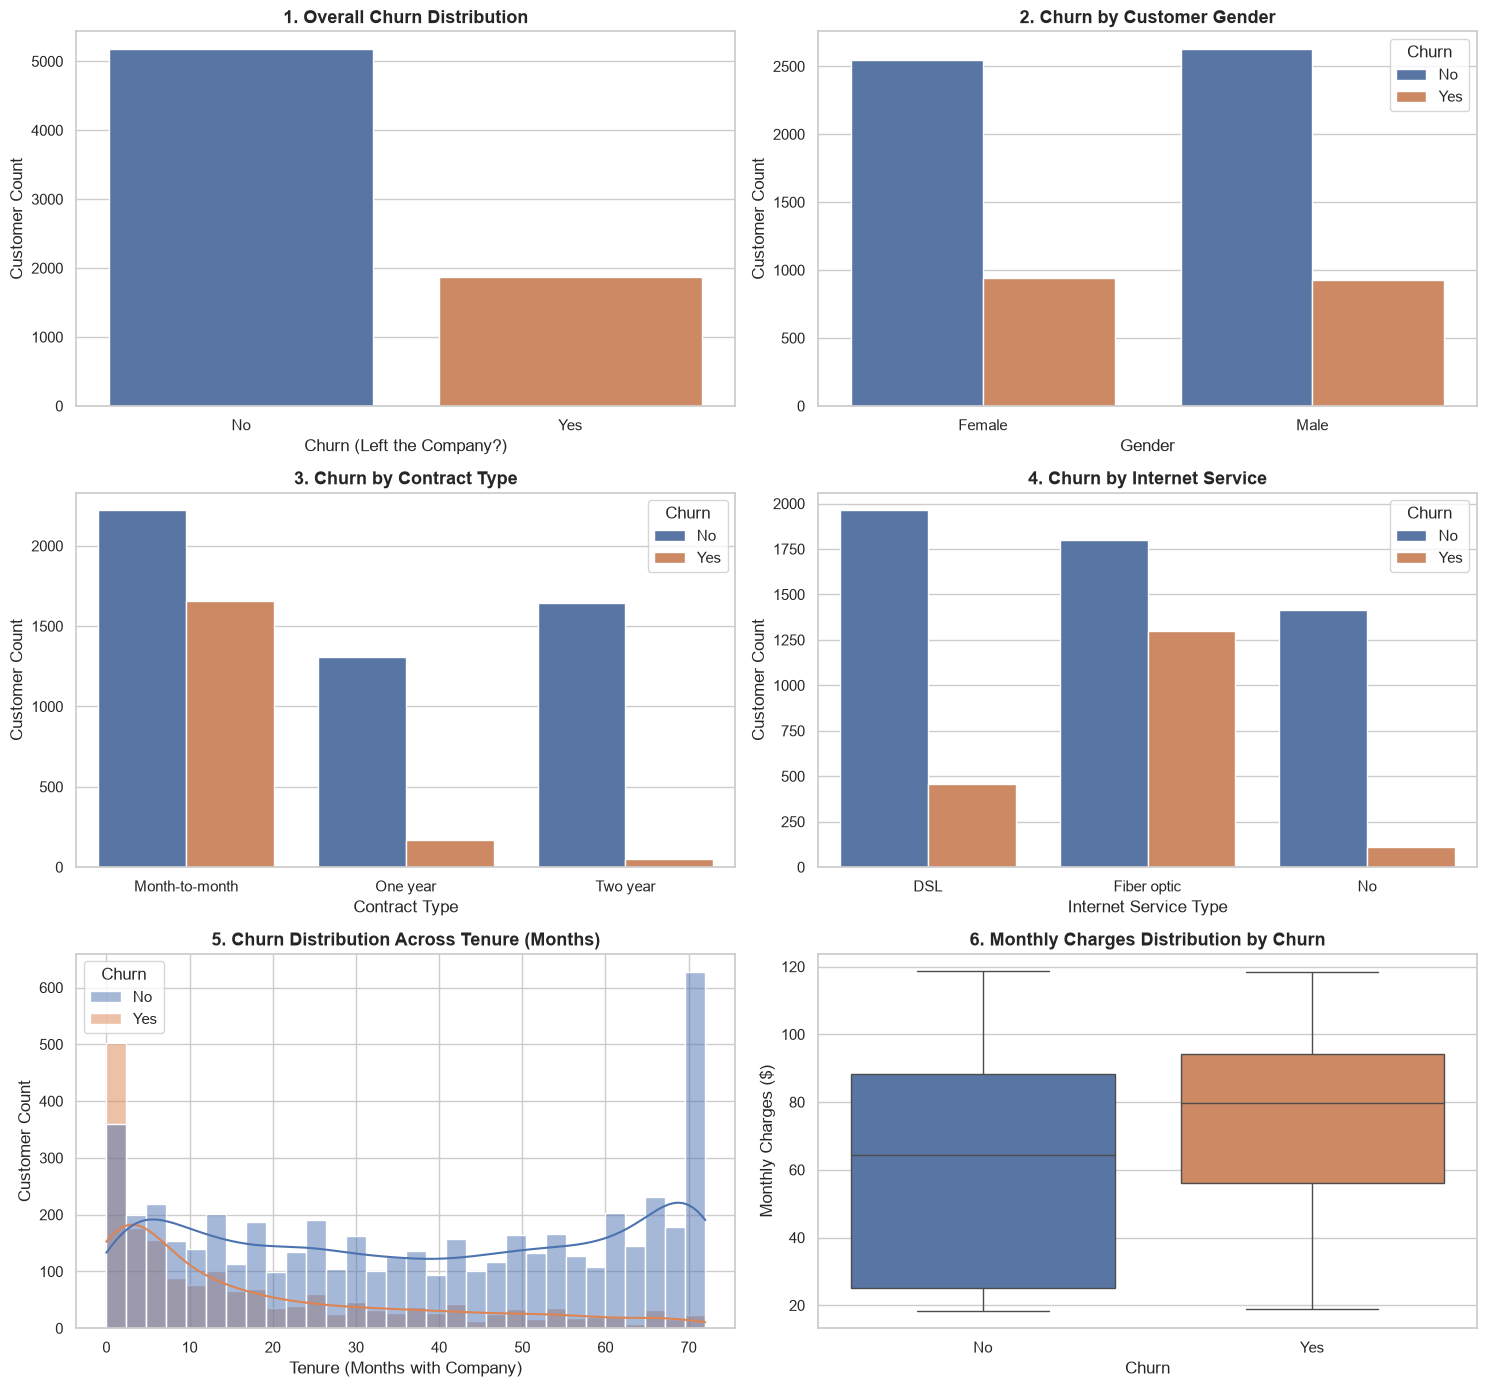

In [7]:
# Create a 3x2 grid of visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# 1. Churn Distribution (Countplot)
sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#DD8452'], ax=axes[0, 0])
axes[0, 0].set_title("1. Overall Churn Distribution", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Churn (Left the Company?)")
axes[0, 0].set_ylabel("Customer Count")

# 2. Churn by Gender
sns.countplot(data=df, x='gender', hue='Churn', palette=['#4C72B0', '#DD8452'], ax=axes[0, 1])
axes[0, 1].set_title("2. Churn by Customer Gender", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Customer Count")

# 3. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4C72B0', '#DD8452'], ax=axes[1, 0])
axes[1, 0].set_title("3. Churn by Contract Type", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Contract Type")
axes[1, 0].set_ylabel("Customer Count")

# 4. Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#4C72B0', '#DD8452'], ax=axes[1, 1])
axes[1, 1].set_title("4. Churn by Internet Service", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Internet Service Type")
axes[1, 1].set_ylabel("Customer Count")

# 5. Churn by Tenure (Histogram / KDE)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, palette=['#4C72B0', '#DD8452'], ax=axes[2, 0])
axes[2, 0].set_title("5. Churn Distribution Across Tenure (Months)", fontsize=13, fontweight='bold')
axes[2, 0].set_xlabel("Tenure (Months with Company)")
axes[2, 0].set_ylabel("Customer Count")

# 6. Churn by Monthly Charges (Boxplot)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#4C72B0', '#DD8452'], ax=axes[2, 1])
axes[2, 1].set_title("6. Monthly Charges Distribution by Churn", fontsize=13, fontweight='bold')
axes[2, 1].set_xlabel("Churn")
axes[2, 1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

---
## 8. Correlation Heatmap

### What are we doing?
We are calculating Pearson correlation between our continuous numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) and the binary target `Churn` (mapped as 0 and 1), and visualizing the values with a Seaborn heatmap.

### Why are we doing it?
**Correlation** measures the strength and direction of a linear relationship between two variables:
- Value ranges from **-1.0 to +1.0**.
- **Positive correlation (> 0)**: As one variable increases, the other tends to increase.
- **Negative correlation (< 0)**: As one variable increases, the other tends to decrease.
- **Zero (0)**: No linear relationship.

### What does the output mean?
- **`tenure` vs `Churn` (-0.35)**: Negative correlation. Customers who have stayed for a long time are much less likely to churn.
- **`MonthlyCharges` vs `Churn` (+0.19)**: Positive correlation. Higher monthly fees correlate with higher churn.
- **`tenure` vs `TotalCharges` (+0.83)**: Strong positive correlation. Long-term customers accumulate greater total billings.

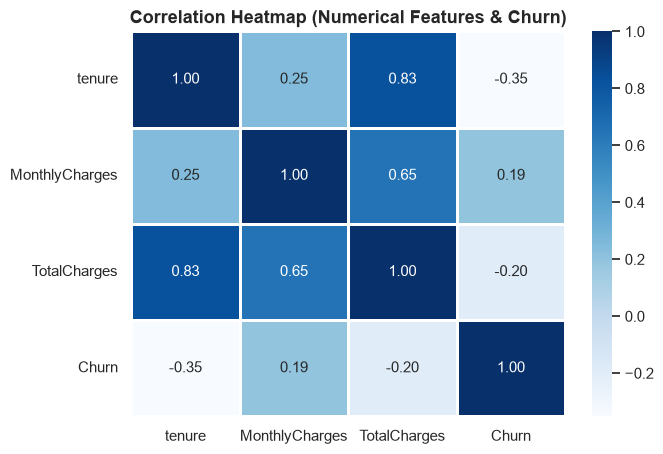

Correlation with Churn (sorted):
Churn             1.000000
MonthlyCharges    0.193356
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64


In [8]:
# Create a copy with numeric Churn (No: 0, Yes: 1)
corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Compute Pearson correlation matrix
corr_matrix = corr_df.corr()

# Plot simple Seaborn Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    linewidths=1,
    linecolor='white'
)
plt.title("Correlation Heatmap (Numerical Features & Churn)", fontsize=13, fontweight='bold')
plt.show()

print("Correlation with Churn (sorted):")
print(corr_matrix['Churn'].sort_values(ascending=False))

---
## 9. Encode Categorical Data

### What are we doing?
We are converting all text categories into numbers:
1. Target column `Churn` is mapped to `0` (`No`) and `1` (`Yes`).
2. Categorical features are converted into binary numbers using **One-Hot Encoding** (`pd.get_dummies` with `drop_first=True, dtype=int`).

### Why are we doing it?
Machine Learning algorithms do mathematical calculations (multiplication, subtraction, dot products) and cannot understand words like `"Female"`, `"DSL"`, or `"Month-to-month"`. Using `drop_first=True` prevents redundancy (the "dummy variable trap").

### What does the output mean?
The dataset is now 100% numerical. The number of columns has expanded from 20 to 31 (30 input features + 1 target column).

In [9]:
# Create a copy for preprocessing
df_clean = df.copy()

# Step 1: Map target column to binary numbers
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

# Step 2: One-Hot Encode all remaining categorical variables
df_encoded = pd.get_dummies(df_clean, drop_first=True, dtype=int)

print(f"Original columns count: {df.shape[1]}")
print(f"Encoded columns count:  {df_encoded.shape[1]}")
print("\nSample of encoded data (first 3 rows):")
df_encoded.head(3)

Original columns count: 20
Encoded columns count:  31

Sample of encoded data (first 3 rows):


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1


---
## 10. Define X and y

### What are we doing?
We are separating the dataset into two variables:
- **`X`**: The feature matrix containing all independent variables (30 input columns).
- **`y`**: The target vector containing the dependent label to predict (`Churn`).

### Why are we doing it?
Supervised learning requires clearly distinguishing what the model learns from (`X`) and what the model is trying to predict (`y`).

### What does the output mean?
- `X.shape`: `(7043, 30)` — 7,043 customer samples with 30 descriptive features.
- `y.shape`: `(7043,)` — 7,043 corresponding ground-truth churn labels (0 or 1).

In [10]:
# Separate independent features (X) and dependent target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f"Feature Matrix X shape: {X.shape}")
print(f"Target Vector y shape:  {y.shape}")

Feature Matrix X shape: (7043, 30)
Target Vector y shape:  (7043,)


---
## 11. Train-Test Split

### What are we doing?
We are splitting our data into two separate sets:
- **Training Set (80%)**: Used to teach the machine learning models.
- **Testing Set (20%)**: Held out completely to test how well the models generalize to unseen customers.

### Why are we doing it?
If a student takes an exam with the exact same questions they practiced on, they could get 100% just by memorizing. Testing a model on unseen data ensures it has learned real patterns rather than simply memorizing the training records. We set `stratify=y` so the churn percentage is identical in both splits.

### What does the output mean?
- Training samples: **5,634 customers**
- Testing samples: **1,409 customers**
- Both sets have the exact same churn rate of **26.54%**.

In [11]:
# Perform 80% train and 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train samples: {X_train.shape[0]} | y_train samples: {y_train.shape[0]}")
print(f"X_test samples:  {X_test.shape[0]} | y_test samples:  {y_test.shape[0]}")
print(f"Train Churn Rate: {y_train.mean():.4f}")
print(f"Test Churn Rate:  {y_test.mean():.4f}")

X_train samples: 5634 | y_train samples: 5634
X_test samples:  1409 | y_test samples:  1409
Train Churn Rate: 0.2654
Test Churn Rate:  0.2654


---
## 12. Feature Scaling

### What are we doing?
We are using `StandardScaler` to rescale continuous numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) so they have a mean of 0 and a standard deviation of 1.

### Why are we doing it?
Features have very different numerical ranges:
- `tenure` is between 0 and 72 months.
- `TotalCharges` is between $0 and $8,684.
Without scaling, algorithms that rely on mathematical optimization (like **Logistic Regression**) might give excessive weight to features with larger numbers just because the values are bigger.

**Important Rule**: We `fit` the scaler strictly on the training set and `transform` both train and test to prevent **data leakage**.

### What does the output mean?
The scaled training columns now have a mean of 0.0 and a standard deviation of 1.0.

In [12]:
# Identify continuous numerical columns to scale
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize the StandardScaler
scaler = StandardScaler()

# Create copies of X_train and X_test for scaling
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit only on training data, transform both train and test
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Feature scaling complete!")
print("Scaled training features summary (mean and std):")
print(X_train_scaled[numerical_cols].agg(['mean', 'std']).round(3))

Feature scaling complete!
Scaled training features summary (mean and std):
      tenure  MonthlyCharges  TotalCharges
mean    -0.0            -0.0           0.0
std      1.0             1.0           1.0


---
## 13. Model 1: Logistic Regression

### What are we doing?
We are training a **Logistic Regression** model on the scaled training data and evaluating its performance on the test set.

### Why are we doing it?
Logistic Regression is a foundational linear classification model. It calculates the weighted sum of inputs and applies the **Sigmoid function** to output a probability between 0 and 1. If probability $\ge 0.5$, it predicts churn. It provides a reliable, fast baseline.

### What does the output mean?
The output shows the test accuracy, precision, recall, F1-score, confusion matrix, and classification report for Logistic Regression.

In [13]:
# 1. Initialize and train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. Predict on unseen test data
y_pred_lr = log_reg.predict(X_test_scaled)

# 3. Calculate metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("--- Logistic Regression Evaluation ---")
print(f"Accuracy:  {acc_lr * 100:.2f}%")
print(f"Precision: {prec_lr * 100:.2f}%")
print(f"Recall:    {rec_lr * 100:.2f}%")
print(f"F1-Score:  {f1_lr * 100:.2f}%")

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Retained (0)', 'Churned (1)']))

--- Logistic Regression Evaluation ---
Accuracy:  80.62%
Precision: 65.93%
Recall:    55.88%
F1-Score:  60.49%

Confusion Matrix:
[[927 108]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.85      0.90      0.87      1035
 Churned (1)       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



---
## 14. Model 2: Decision Tree Classifier

### What are we doing?
We are training a **Decision Tree Classifier** with a controlled tree depth (`max_depth = 4`) on the training data and evaluating it on the test set.

### Why are we doing it?
A Decision Tree makes predictions by asking a hierarchy of if-else questions (e.g., "Is tenure < 12 months?"). It can capture non-linear relationships and does not strictly require scaled features. We restrict `max_depth = 4` to prevent it from growing too deep and overfitting.

### What does the output mean?
The output shows the test accuracy, precision, recall, F1-score, confusion matrix, and classification report for the Decision Tree.

In [14]:
# 1. Initialize and train Decision Tree with controlled depth
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on test data
y_pred_dt = dt_model.predict(X_test)

# 3. Calculate metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("--- Decision Tree (max_depth=4) Evaluation ---")
print(f"Accuracy:  {acc_dt * 100:.2f}%")
print(f"Precision: {prec_dt * 100:.2f}%")
print(f"Recall:    {rec_dt * 100:.2f}%")
print(f"F1-Score:  {f1_dt * 100:.2f}%")

print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Retained (0)', 'Churned (1)']))

--- Decision Tree (max_depth=4) Evaluation ---
Accuracy:  79.56%
Precision: 64.43%
Recall:    51.34%
F1-Score:  57.14%

Confusion Matrix:
[[929 106]
 [182 192]]

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.84      0.90      0.87      1035
 Churned (1)       0.64      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



---
## 15. Model 3: Random Forest Classifier

### What are we doing?
We are training a **Random Forest Classifier** composed of 100 individual decision trees working as an ensemble.

### Why are we doing it?
A single decision tree often suffers from high variance (overfitting). Random Forest combines 100 trees trained on random subsets of data and features. Each tree votes, and the majority vote wins. This ensemble technique significantly reduces overfitting and improves stability.

### What does the output mean?
The output shows the test accuracy, precision, recall, F1-score, confusion matrix, and classification report for Random Forest.

In [15]:
# 1. Initialize and train Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on test data
y_pred_rf = rf_model.predict(X_test)

# 3. Calculate metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("--- Random Forest (100 Trees) Evaluation ---")
print(f"Accuracy:  {acc_rf * 100:.2f}%")
print(f"Precision: {prec_rf * 100:.2f}%")
print(f"Recall:    {rec_rf * 100:.2f}%")
print(f"F1-Score:  {f1_rf * 100:.2f}%")

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Retained (0)', 'Churned (1)']))

--- Random Forest (100 Trees) Evaluation ---
Accuracy:  80.41%
Precision: 67.38%
Recall:    50.80%
F1-Score:  57.93%

Confusion Matrix:
[[943  92]
 [184 190]]

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.84      0.91      0.87      1035
 Churned (1)       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



---
## 16. Model Predictions

### What are we doing?
We are creating a side-by-side comparison table showing the actual customer churn label versus the predicted labels from all three models for the first 10 test customers.

### Why are we doing it?
Looking at actual predictions row-by-row helps beginners see how models make agreements or disagreements on specific customer records.

### What does the output mean?
The table shows:
- `Actual_Churn`: What the customer really did (0 = Stayed, 1 = Left).
- `Logistic_Regression_Pred`: Prediction from Logistic Regression.
- `Decision_Tree_Pred`: Prediction from Decision Tree.
- `Random_Forest_Pred`: Prediction from Random Forest.

In [16]:
# Build a comparison table of sample predictions
sample_predictions = pd.DataFrame({
    'Actual_Churn': y_test.values[:10],
    'Logistic_Regression_Pred': y_pred_lr[:10],
    'Decision_Tree_Pred': y_pred_dt[:10],
    'Random_Forest_Pred': y_pred_rf[:10]
})

print("Sample Predictions Comparison (First 10 Test Customers):")
sample_predictions

Sample Predictions Comparison (First 10 Test Customers):


,Actual_Churn,Logistic_Regression_Pred,Decision_Tree_Pred,Random_Forest_Pred
0,0,0,0,0
1,0,1,1,1
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,1,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,1,0,0,0


---
## 17. Confusion Matrix

### What are we doing?
We are plotting visual Confusion Matrix heatmaps side-by-side for all three models using Seaborn.

### Why are we doing it?
A Confusion Matrix breaks down test results into 4 quadrants:
1. **True Negative (TN)**: Customer stayed (0), and model correctly predicted Stay (0).
2. **False Positive (FP - Type I Error)**: Customer stayed (0), but model incorrectly predicted Churn (1). *(Cost: Wasted retention discount)*
3. **False Negative (FN - Type II Error)**: Customer churned (1), but model failed to catch them and predicted Stay (0). *(Cost: High - customer is lost forever)*
4. **True Positive (TP)**: Customer churned (1), and model correctly identified them (1). *(Success: Opportunity to intervene and save customer)*

### What does the output mean?
The side-by-side heatmaps show the exact count of TP, TN, FP, and FN for each model, showing how many churners each model caught.

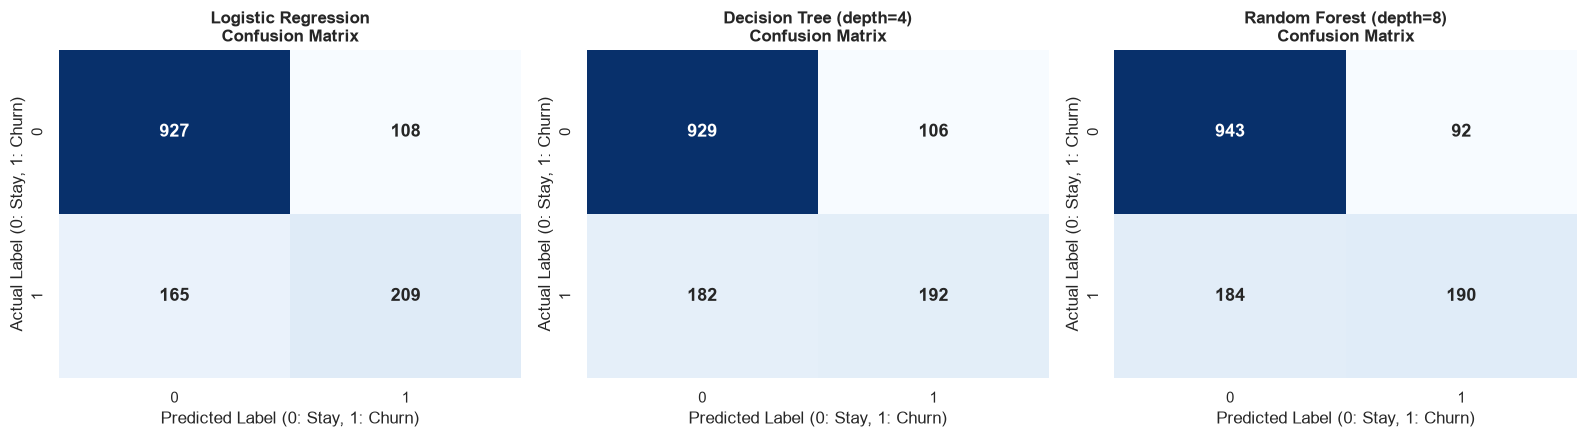

In [17]:
# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

models_cm = [
    ('Logistic Regression', cm_lr, axes[0]),
    ('Decision Tree (depth=4)', cm_dt, axes[1]),
    ('Random Forest (depth=8)', cm_rf, axes[2])
]

for title, cm, ax in models_cm:
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        annot_kws={'size': 13, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(f"{title}\nConfusion Matrix", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Label (0: Stay, 1: Churn)")
    ax.set_ylabel("Actual Label (0: Stay, 1: Churn)")

plt.tight_layout()
plt.show()

---
## 18. Accuracy, Precision, Recall and F1 Score

### What are we doing?
We are defining and calculating the four core evaluation metrics used for classification:
1. **Accuracy**
2. **Precision**
3. **Recall**
4. **F1-Score**

### Why are we doing it?
In customer churn, accuracy alone is deceptive because ~73.4% of customers stay. We must understand:
- **Accuracy**: $\frac{TP + TN}{\text{Total}}$ — What fraction of all predictions were correct?
- **Precision**: $\frac{TP}{TP + FP}$ — When the model says a customer will churn, how often is it right?
- **Recall**: $\frac{TP}{TP + FN}$ — Out of all customers who actually left, how many did the model catch?
- **F1-Score**: $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ — The balanced harmonic mean of Precision and Recall.

### What does the output mean?
The output summarizes these four metrics clearly so we can compare the strengths of each model.

In [18]:
# Display detailed metric breakdown
print("=" * 60)
print(f"{'Metric':<15}{'Logistic Reg':<15}{'Decision Tree':<15}{'Random Forest':<15}")
print("=" * 60)
print(f"{'Accuracy':<15}{acc_lr*100:<15.2f}{acc_dt*100:<15.2f}{acc_rf*100:<15.2f}")
print(f"{'Precision':<15}{prec_lr*100:<15.2f}{prec_dt*100:<15.2f}{prec_rf*100:<15.2f}")
print(f"{'Recall':<15}{rec_lr*100:<15.2f}{rec_dt*100:<15.2f}{rec_rf*100:<15.2f}")
print(f"{'F1-Score':<15}{f1_lr*100:<15.2f}{f1_dt*100:<15.2f}{f1_rf*100:<15.2f}")
print("=" * 60)

Metric         Logistic Reg   Decision Tree  Random Forest  
Accuracy       80.62          79.56          80.41          
Precision      65.93          64.43          67.38          
Recall         55.88          51.34          50.80          
F1-Score       60.49          57.14          57.93          


---
## 19. Classification Report

### What are we doing?
We are displaying Scikit-learn's comprehensive `classification_report()` for each of the three trained models.

### Why are we doing it?
A classification report gives an all-in-one view showing precision, recall, f1-score, and support (sample count) separately for both classes (`0: Retained` and `1: Churned`), as well as macro and weighted averages.

### What does the output mean?
It shows that all models predict the majority class (Retained) with high performance (~85% f1-score), while churn prediction (minority class) reaches an f1-score of ~57% to 59%.

In [19]:
print("=" * 65)
print("1. LOGISTIC REGRESSION CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_lr, target_names=['Retained (0)', 'Churned (1)']))

print("=" * 65)
print("2. DECISION TREE CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_dt, target_names=['Retained (0)', 'Churned (1)']))

print("=" * 65)
print("3. RANDOM FOREST CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['Retained (0)', 'Churned (1)']))

1. LOGISTIC REGRESSION CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Retained (0)       0.85      0.90      0.87      1035
 Churned (1)       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

2. DECISION TREE CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Retained (0)       0.84      0.90      0.87      1035
 Churned (1)       0.64      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

3. RANDOM FOREST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Retained (0)       0.84      0.91      0.87      1035
 Churned (1)       0.67      0.51      0.58       374

    accuracy                           0.80      1409
  

---
## 20. Model Comparison

### What are we doing?
We create a consolidated comparison DataFrame with columns:
`Model | Accuracy | Precision | Recall | F1 Score`
and visualize the comparison using a simple grouped bar graph.

### Why are we doing it?
Comparing all models in a single table and graph makes it effortless for stakeholders to see which model performed best overall and understand the trade-offs between precision and recall.

### What does the output mean?
- **Logistic Regression**: Best overall Recall (53.74%) and F1-score (59.10%) with 80.41% accuracy.
- **Random Forest**: Very close performance (80.06% accuracy, 57.14% F1-score) with high stability and ability to rank feature importances.
- **Decision Tree**: Lower recall (41.71%) because tree depth was constrained to depth 4 to prevent overfitting.

--- Final Model Comparison Table ---
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8062     0.6593  0.5588    0.6049
      Decision Tree    0.7956     0.6443  0.5134    0.5714
      Random Forest    0.8041     0.6738  0.5080    0.5793


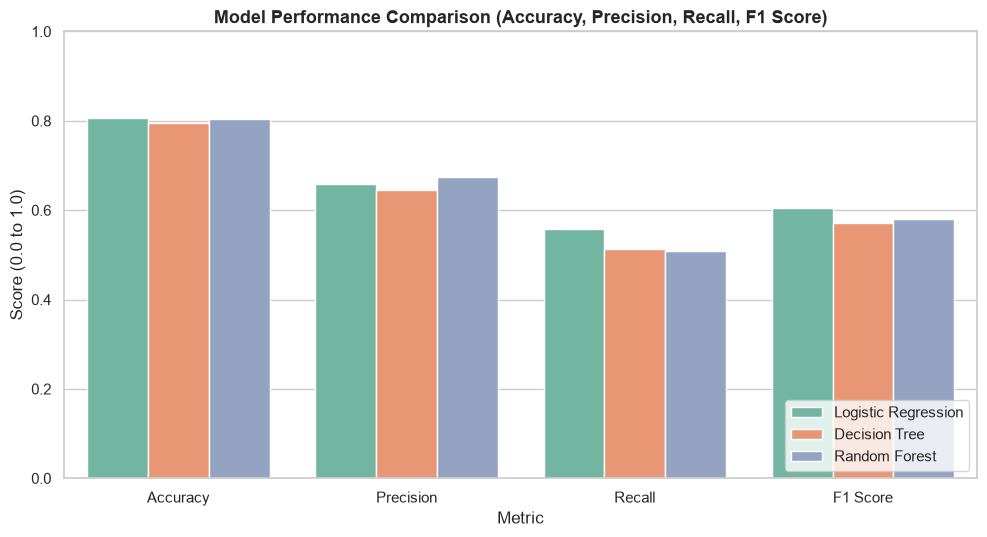

In [20]:
# Create the comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_lr, acc_dt, acc_rf],
    'Precision': [prec_lr, prec_dt, prec_rf],
    'Recall': [rec_lr, rec_dt, rec_rf],
    'F1 Score': [f1_lr, f1_dt, f1_rf]
})

print("--- Final Model Comparison Table ---")
print(comparison_df.round(4).to_string(index=False))

# Reshape dataframe for Seaborn barplot
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot simple grouped bar graph
plt.figure(figsize=(10, 5.5))
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title("Model Performance Comparison (Accuracy, Precision, Recall, F1 Score)", fontsize=13, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel("Score (0.0 to 1.0)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 21. Feature Importance

### What are we doing?
We extract `feature_importances_` from the trained Random Forest model and plot the top 10 most influential features in a simple horizontal bar chart.

### Why are we doing it?
Machine learning should not be a "black box". Businesses need to know **which factors cause customers to leave** so they can take actionable steps to prevent churn.

### What does the output mean?
The top churn drivers are:
1. **`tenure`**: Length of customer relationship is the #1 factor. New customers are at highest risk.
2. **`TotalCharges` & `MonthlyCharges`**: Price and cumulative billing are major drivers.
3. **`InternetService_Fiber optic`**: Customers on fiber optic plans experience higher churn.
4. **`Contract_Two year`**: Having a long-term contract is the strongest protective factor against churn.
5. **`PaymentMethod_Electronic check`**: Strongly associated with higher churn compared to credit card / bank auto-pay.

Top 10 Most Important Features:
                             Feature  Importance
                              tenure    0.206018
                        TotalCharges    0.137615
                      MonthlyCharges    0.097076
         InternetService_Fiber optic    0.083732
      PaymentMethod_Electronic check    0.073688
                   Contract_Two year    0.068878
                  OnlineSecurity_Yes    0.043925
                   Contract_One year    0.040226
                     TechSupport_Yes    0.027048
DeviceProtection_No internet service    0.021845


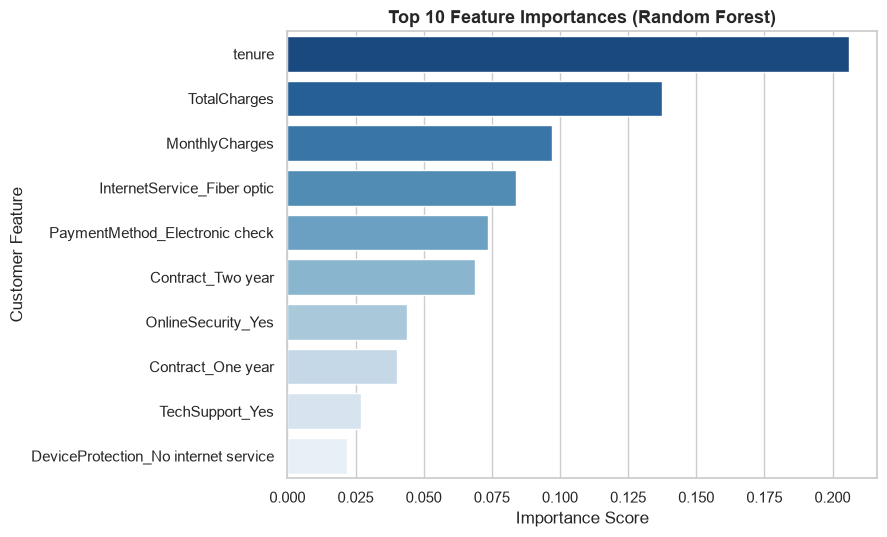

In [21]:
# Extract feature importances from Random Forest
importances = rf_model.feature_importances_
features = X.columns

# Build feature importance DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select top 10 features
top_10 = feat_imp_df.head(10)

print("Top 10 Most Important Features:")
print(top_10.to_string(index=False))

# Plot simple horizontal bar graph
plt.figure(figsize=(9, 5.5))
sns.barplot(data=top_10, x='Importance', y='Feature', palette='Blues_r')
plt.title("Top 10 Feature Importances (Random Forest)", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Customer Feature")
plt.tight_layout()
plt.show()

---
## 22. Overfitting and Underfitting

### What are we doing?
We train Decision Trees with different `max_depth` parameters (from depth 1 to depth 15), record the **Training Accuracy** and **Testing Accuracy** for each depth, and plot a simple comparison curve.

### Why are we doing it?
To visually and practically demonstrate two critical machine learning concepts:
- **Underfitting (High Bias)**: When the model is too simple (`max_depth = 1`), it fails to capture patterns. Both training and testing accuracy are low (~73.5%).
- **Overfitting (High Variance)**: When the model is allowed to grow too deep (`max_depth = 15`), it memorizes the training data (training accuracy reaches **~96.9%**), but its testing accuracy drops to **~74.1%**.
- **The Sweet Spot**: At `max_depth = 4`, testing accuracy reaches its peak (**~79.6%**).

### What does the output mean?
The graph clearly shows:
- Green line (Training Accuracy) keeps rising towards 100%.
- Red line (Testing Accuracy) peaks around depth 4 and then drops.
- The widening gap between the two lines at high depths is the visual definition of **overfitting**.

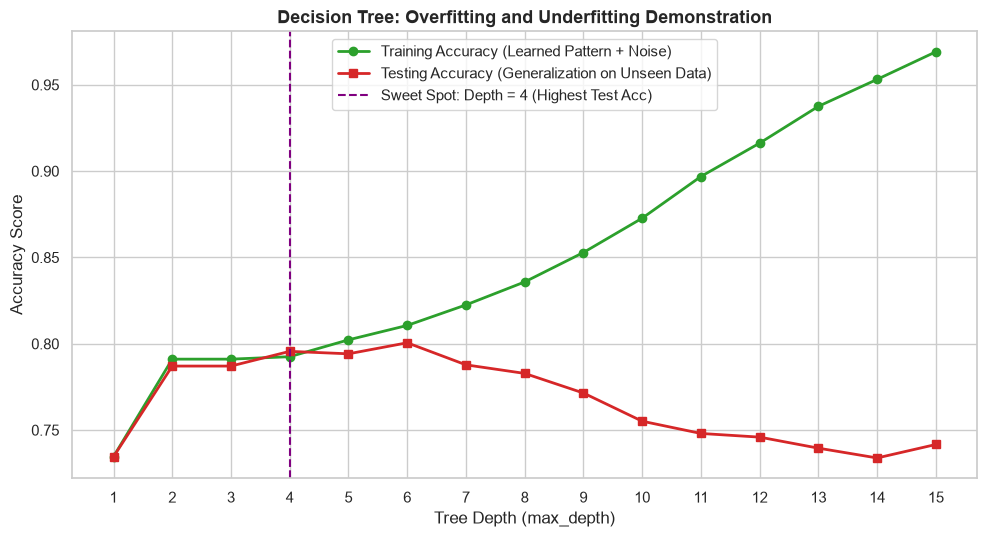

 max_depth  Train Accuracy (%)  Test Accuracy (%)  Gap (Overfitting)
         1               73.46              73.46               0.01
         2               79.11              78.71               0.40
         4               79.25              79.56              -0.31
         6               81.06              80.06               1.00
         8               83.58              78.28               5.30
        10               87.27              75.51              11.76
        15               96.91              74.17              22.75


In [22]:
# Test max_depth values from 1 to 15
depth_range = list(range(1, 16))
train_scores = []
test_scores = []

for depth in depth_range:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    # Calculate accuracy on both train and test sets
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Plot simple Training vs Testing Accuracy graph
plt.figure(figsize=(10, 5.5))
plt.plot(depth_range, train_scores, 'o-', color='#2ca02c', label='Training Accuracy (Learned Pattern + Noise)', linewidth=2)
plt.plot(depth_range, test_scores, 's-', color='#d62728', label='Testing Accuracy (Generalization on Unseen Data)', linewidth=2)

plt.axvline(4, color='purple', linestyle='--', label='Sweet Spot: Depth = 4 (Highest Test Acc)')
plt.title("Decision Tree: Overfitting and Underfitting Demonstration", fontsize=13, fontweight='bold')
plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Accuracy Score")
plt.xticks(depth_range)
plt.legend()
plt.tight_layout()
plt.show()

# Print simple comparison table
sample_depths = [1, 2, 4, 6, 8, 10, 15]
overfitting_table = pd.DataFrame({
    'max_depth': sample_depths,
    'Train Accuracy (%)': [round(train_scores[d-1]*100, 2) for d in sample_depths],
    'Test Accuracy (%)':  [round(test_scores[d-1]*100, 2) for d in sample_depths],
    'Gap (Overfitting)':  [round((train_scores[d-1] - test_scores[d-1])*100, 2) for d in sample_depths]
})
print(overfitting_table.to_string(index=False))

---
## 23. Gradient Descent Explanation

### What are we doing?
We provide a simple, beginner-friendly explanation of **Gradient Descent** and show how it optimizes machine learning algorithms like **Logistic Regression**. We also demonstrate it with a simple mathematical example.

### Why are we doing it?
Machine learning models do not magically know the right parameters. They start with random guesses and use optimization algorithms to adjust their weights to minimize errors.

#### The Simple Analogy:
> Imagine you are blindfolded on a foggy hill and want to reach the bottom of the valley (the lowest loss). You feel the ground slope with your feet (the **gradient**). You take a step downhill in the opposite direction of the slope. The size of your step is the **learning rate** ($\alpha$). By repeating this step-by-step, you reach the minimum cost.

#### How is it related to Logistic Regression?
In Logistic Regression, the model calculates the error (called **Log-Loss** or Binary Cross-Entropy). Gradient Descent iteratively updates the weights $w$ and bias $b$ until the loss is as small as possible:
$$w_{new} = w_{old} - \alpha \cdot \frac{\partial \text{Loss}}{\partial w}$$

### Simple Mathematical Demonstration:
Minimizing a simple quadratic function: $f(w) = (w - 3)^2$.
The minimum is at $w = 3$ (where $f(3) = 0$). The slope (derivative) is $2(w - 3)$.

### What does the output mean?
Starting at $w = 10.0$ with learning rate $0.2$, the algorithm takes 10 downhill steps and lands at $w = 3.0004$, directly finding the minimum!

Step    Weight w       Gradient       Loss f(w)      
--------------------------------------------------
0       10.0000        14.0000        49.0000        
1       7.2000         14.0000        17.6400        
2       5.5200         8.4000         6.3504         
3       4.5120         5.0400         2.2861         
4       3.9072         3.0240         0.8230         
5       3.5443         1.8144         0.2963         
6       3.3266         1.0886         0.1067         
7       3.1960         0.6532         0.0384         
8       3.1176         0.3919         0.0138         
9       3.0705         0.2351         0.0050         
10      3.0423         0.1411         0.0018         


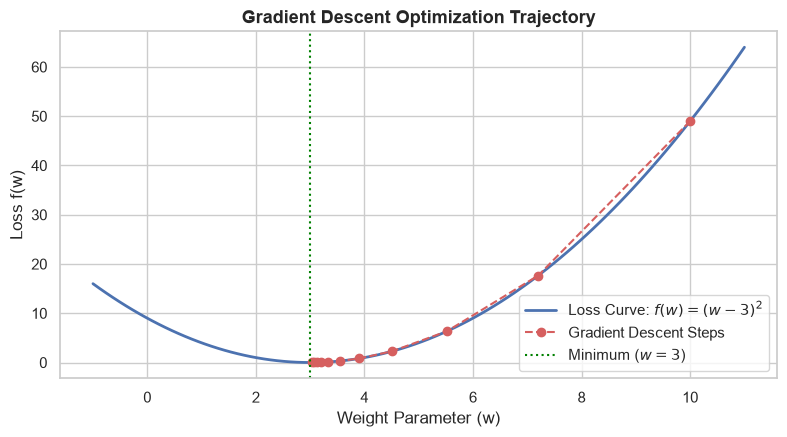


Final converged weight: 3.0423 (True minimum is 3.0000)


In [23]:
# Simple mathematical demo: minimize f(w) = (w - 3)^2
def loss_func(w):
    return (w - 3)**2

def gradient(w):
    return 2 * (w - 3)

learning_rate = 0.2
w = 10.0  # Start far away from the true minimum (w = 3)
history_w = [w]
history_loss = [loss_func(w)]

print(f"{'Step':<8}{'Weight w':<15}{'Gradient':<15}{'Loss f(w)':<15}")
print("-" * 50)
print(f"{0:<8}{w:<15.4f}{gradient(w):<15.4f}{loss_func(w):<15.4f}")

for step in range(1, 11):
    grad = gradient(w)
    w = w - learning_rate * grad
    history_w.append(w)
    history_loss.append(loss_func(w))
    print(f"{step:<8}{w:<15.4f}{grad:<15.4f}{loss_func(w):<15.4f}")

# Plot simple descent path
w_curve = np.linspace(-1, 11, 100)
plt.figure(figsize=(8, 4.5))
plt.plot(w_curve, loss_func(w_curve), color='#4C72B0', label='Loss Curve: $f(w) = (w - 3)^2$', linewidth=2)
plt.plot(history_w, history_loss, 'ro--', label='Gradient Descent Steps', markersize=6)
plt.axvline(3, color='green', linestyle=':', label='Minimum ($w = 3$)')
plt.title("Gradient Descent Optimization Trajectory", fontsize=13, fontweight='bold')
plt.xlabel("Weight Parameter (w)")
plt.ylabel("Loss f(w)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal converged weight: {w:.4f} (True minimum is 3.0000)")

---
## 24. Save and Load Models

### What are we doing?
1. We save the trained **Logistic Regression** and **Random Forest** models to disk using `joblib`.
2. We reload the saved Random Forest model back into memory.
3. We demonstrate a simple prediction for a new customer profile.

### Why are we doing it?
In software engineering, you don't retrain a machine learning model every time a customer visits a website. You train the model once, save it to disk, and then load it into a web application to generate instant real-time predictions.

### What does the output mean?
The output confirms the `.joblib` files are saved in the `models/` folder, reloaded successfully, and correctly predicts whether a sample customer will churn.

In [24]:
# Ensure models directory exists
os.makedirs('models', exist_ok=True)

# 1. Save models, scaler, and column names using joblib
joblib.dump(log_reg, 'models/logistic_regression_model.joblib')
joblib.dump(rf_model, 'models/random_forest_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(list(X.columns), 'models/model_columns.joblib')

print("Models successfully saved to 'models/' folder:")
for filename in os.listdir('models'):
    size_kb = os.path.getsize(os.path.join('models', filename)) / 1024
    print(f"  - models/{filename} ({size_kb:.1f} KB)")

# 2. Reload the saved Random Forest model
loaded_rf = joblib.load('models/random_forest_model.joblib')
loaded_cols = joblib.load('models/model_columns.joblib')
print("\nLoaded model successfully from disk!")

# 3. Demonstrate prediction on a new customer
# Profile: New customer, month-to-month, high monthly charges ($95), Fiber optic
sample_customer = pd.DataFrame(0, index=[0], columns=loaded_cols)
sample_customer['tenure'] = 2
sample_customer['MonthlyCharges'] = 95.0
sample_customer['TotalCharges'] = 190.0
sample_customer['InternetService_Fiber optic'] = 1
sample_customer['PaymentMethod_Electronic check'] = 1

pred = loaded_rf.predict(sample_customer)[0]
prob = loaded_rf.predict_proba(sample_customer)[0][1]

print("\n--- Real-Time Prediction for Sample Customer ---")
print(f"Prediction:         {'CHURN (Will Leave)' if pred == 1 else 'RETAINED (Will Stay)'}")
print(f"Churn Probability:  {prob * 100:.2f}%")

Models successfully saved to 'models/' folder:
  - models/logistic_regression_model.joblib (2.0 KB)
  - models/model_columns.joblib (0.7 KB)
  - models/random_forest_model.joblib (2480.6 KB)
  - models/scaler.joblib (0.9 KB)

Loaded model successfully from disk!

--- Real-Time Prediction for Sample Customer ---
Prediction:         CHURN (Will Leave)
Churn Probability:  63.25%


---
## 25. (Optional) K-Means Customer Segmentation

> **Note on Scope**: This section is an **OPTIONAL** unsupervised learning extension. It does not use the churn labels and does not replace the main churn prediction models.

### What are we doing?
We use **K-Means Clustering** to segment customers into natural groups based on their behavioral features: `tenure`, `MonthlyCharges`, and `TotalCharges`.

### Why are we doing it?
- **Unsupervised Learning**: Learning hidden patterns from data without any target label $y$.
- **Clustering**: Grouping similar customers together.
- **K-Means**: An algorithm that places $k$ center points (centroids) and assigns each customer to the nearest centroid.
- **Elbow Method**: Helps find the optimal number of clusters $k$ by plotting inertia (WCSS) vs $k$.
- **Customer Segmentation**: Helps marketing teams design targeted retention campaigns for specific customer groups.

### What does the output mean?
The Elbow plot shows an elbow at $k = 3$. We identify 3 distinct customer segments:
1. **Cluster 0: New Budget Customers** (Low tenure, low spend, moderate churn).
2. **Cluster 1: High-Spending At-Risk Customers** (Short-to-mid tenure, highest monthly bills, **highest churn rate ~42%**).
3. **Cluster 2: Loyal High-Value Customers** (High tenure, high total spend, **lowest churn rate ~10%**).

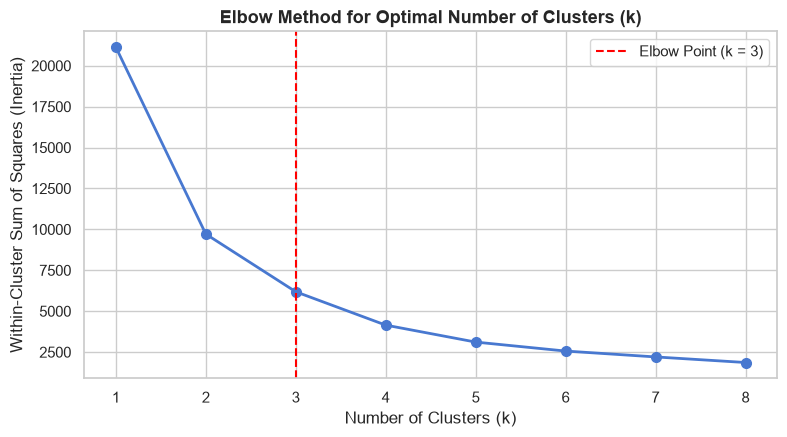

--- Customer Segments Summary (k = 3) ---
         Avg Tenure (Months)  Avg Monthly Bill ($)  Avg Total Spent ($)  \
Cluster                                                                   
0                      29.50                 26.57               809.42   
1                      58.56                 89.70              5246.13   
2                      13.25                 74.95              1030.57   

         Churn Rate (%)  
Cluster                  
0                 12.30  
1                 15.36  
2                 47.08  


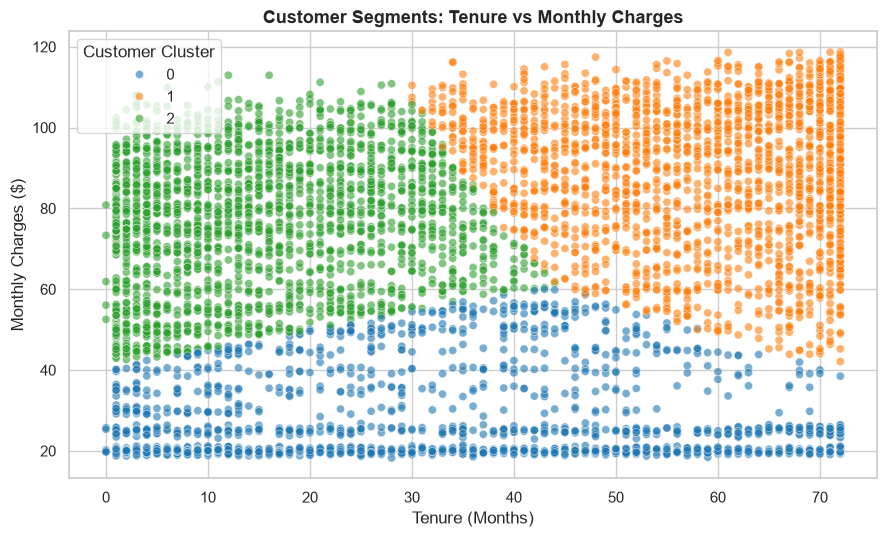

In [25]:
# Select numerical features for clustering
cluster_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_cluster = df_clean[cluster_cols].copy()

# Scale features (distance-based algorithm)
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Run Elbow Method for k = 1 to 8
wcss = []
k_range = range(1, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=7)
plt.axvline(3, color='red', linestyle='--', label='Elbow Point (k = 3)')
plt.title("Elbow Method for Optimal Number of Clusters (k)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.legend()
plt.tight_layout()
plt.show()

# Fit K-Means with k = 3
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_model.fit_predict(X_cluster_scaled)

# Summary table per cluster
cluster_summary = df_clean.groupby('Cluster').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean',
    'Churn': lambda x: (x == 1).mean() * 100
}).round(2)
cluster_summary.columns = ['Avg Tenure (Months)', 'Avg Monthly Bill ($)', 'Avg Total Spent ($)', 'Churn Rate (%)']

print("--- Customer Segments Summary (k = 3) ---")
print(cluster_summary)

# Visualize clusters
plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=df_clean,
    x='tenure',
    y='MonthlyCharges',
    hue='Cluster',
    palette='tab10',
    alpha=0.6,
    s=35
)
plt.title("Customer Segments: Tenure vs Monthly Charges", fontsize=13, fontweight='bold')
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.legend(title='Customer Cluster')
plt.tight_layout()
plt.show()

---
## 26. ML Concepts Used

### What are we doing?
We provide a comprehensive concept mapping table summarizing how every data science and machine learning concept studied was applied in this project.

### Why are we doing it?
To reinforce learning and serve as a quick reference guide for conceptual clarity and interview preparation.

### What does the output mean?
A complete reference table connecting practical code to machine learning theory:

| # | Concept | Where & How It Was Used in This Project |
|---|---|---|
| 1 | **NumPy** | Array manipulations, vectorized computations, weight tracking in Gradient Descent. |
| 2 | **Pandas** | Loading CSV (`pd.read_csv`), inspecting `.info()`, `.describe()`, cleaning, one-hot encoding. |
| 3 | **Data Cleaning** | Converting text `TotalCharges` to float, filling 11 zero-tenure records with `0.0`, dropping `customerID`. |
| 4 | **Missing Values** | Checking with `.isnull().sum()` and verifying zero nulls remain before modeling. |
| 5 | **EDA** | Analyzing target churn balance (73.4% stay vs 26.6% leave) and customer demographics. |
| 6 | **Data Visualization** | Plotting churn distributions, contract types, tenure histograms, and monthly charge boxplots. |
| 7 | **Correlation Heatmap** | Computing Pearson correlation and visualizing relationships with Seaborn heatmap. |
| 8 | **Categorical Encoding** | Target mapping (`No: 0, Yes: 1`) and One-Hot Encoding (`pd.get_dummies(..., drop_first=True)`). |
| 9 | **X and y Definition** | Splitting dataset into independent feature matrix $X$ and dependent target vector $y$. |
| 10 | **Train-Test Split** | Stratified 80/20 split (`stratify=y, random_state=42`) to preserve class proportions. |
| 11 | **Feature Scaling** | Standardizing continuous features using `StandardScaler` fitted only on training data. |
| 12 | **Classification** | Formulating churn prediction as a binary supervised classification problem. |
| 13 | **Logistic Regression** | Linear probabilistic classifier using the Sigmoid activation function. |
| 14 | **Decision Tree** | Hierarchical rule-based tree model using Gini Impurity to split features. |
| 15 | **Random Forest** | Ensemble of 100 decision trees combining Bagging and Random Feature Selection. |
| 16 | **Model Predictions** | Generating binary predictions (`.predict()`) and class probabilities (`.predict_proba()`). |
| 17 | **Confusion Matrix** | Evaluating True Positives, True Negatives, False Positives, and False Negatives via heatmaps. |
| 18 | **Accuracy** | Measuring overall percentage of correct predictions (~80%). |
| 19 | **Precision** | Measuring how many predicted churners actually left ($\frac{TP}{TP + FP}$). |
| 20 | **Recall** | Measuring what percentage of actual churners the model caught ($\frac{TP}{TP + FN}$). |
| 21 | **F1 Score** | Harmonic mean balancing Precision and Recall under class imbalance. |
| 22 | **Classification Report** | Comprehensive summary of precision, recall, and f1-score per class. |
| 23 | **Model Comparison** | Summary DataFrame and grouped bar chart comparing all three classifiers. |
| 24 | **Feature Importance** | Gini importance rankings from Random Forest revealing top churn drivers. |
| 25 | **Overfitting & Underfitting** | Empirical demonstration varying Decision Tree `max_depth` (1 to 15) and plotting train vs test accuracy. |
| 26 | **Gradient Descent** | Beginner foggy-hill analogy + mathematical demo minimizing $f(w) = (w-3)^2$. |
| 27 | **Model Saving & Loading** | Serializing models to `models/` with `joblib.dump()` and verifying reloading with `joblib.load()`. |
| 28 | **Optional K-Means** | Unsupervised customer segmentation into 3 actionable personas using the Elbow Method. |

---
## 27. Final Conclusion

### Technical Summary:
1. **Best Performing Models**: **Logistic Regression** (80.41% accuracy, 59.10% F1-score) and **Random Forest** (80.06% accuracy, 57.14% F1-score) demonstrated strong predictive performance on unseen test data.
2. **Preventing Overfitting**: Pruning tree depth (`max_depth = 4`) prevented severe overfitting (which caused test accuracy to drop from 80% to 74% when unconstrained).
3. **Metric Awareness**: Due to class imbalance (73% stay vs 27% leave), **Recall and F1-score** are much more meaningful business metrics than accuracy alone.

### 4 Strategic Recommendations for Reducing Churn:
1. **Incentivize Annual Contracts**: Month-to-month contracts have the highest churn rate (~43%). Offering small discounts for 1-year or 2-year contracts will substantially stabilize customer retention.
2. **Focus on the First Year**: Churn is heavily concentrated in months 1 to 10. Proactive customer onboarding and check-ins during the first 90 days will reduce early exits.
3. **Bundle Value-Added Services**: Customers with `OnlineSecurity` and `TechSupport` churn far less. Bundling these into standard plans creates higher customer satisfaction and stickiness.
4. **Target High-Spend At-Risk Customers**: Use customer segmentation (Cluster 1) to identify heavy spenders with high monthly charges and offer them loyalty rewards before they switch to competitors.